# Policy-Aware RAG Evaluation Analysis

This notebook analyzes the evaluation artifact loaded by `RESULTS_PATH`, and it summarizes policy outcomes, end-to-end latency, instrumented pipeline latency, token estimates, per-step telemetry, semantic spokesperson review behavior, and optional RAGAS quality metrics.

## Model
It is suggested to use gpt-4o-mini to evaluate the model as the results would typically be more consistent given the change in how temperature is treated in the new frontier models

## Measurement Scope

- `http_latency_ms` is the client-side wall-clock duration of the complete `POST /api/rag` request.
- `total_step_latency_ms` is the sum of the named audit steps returned for that request, including intent validation, context retrieval, base RAG generation, deterministic spokesperson validation, semantic policy review when required, and output redaction when those steps are available.
- The difference between these latency measures includes work outside the step timers, such as model initialization, embedding generation, runtime overhead, network activity, and audit persistence.
- Token counts are estimates generated by the evaluation harness using a four-characters-per-token heuristic; they are not provider billing or tokenizer measurements.
- Answer token usage is split by stage: `BaseRAG` is the generated answer before spokesperson processing, `SpokespersonValidation` records deterministic guardrail input and output estimates, `SemanticPolicyReview` records secondary LLM prompt, completion, total, decision, and latency estimates, and `OutputRedaction` records the final response estimate.
- Semantic review is a secondary process. Deterministic authorization remains authoritative; semantic review should transform restricted outputs when required and must not reject an answer only for relevance or completeness.
- RAGAS contexts are resolved from audited document IDs to document bodies; source IDs are retained separately for traceability.

## Interpretation

Pass rate is calculated from the evaluator's `passed` field and grouped by `case_type`. A policy denial is a passing result when denial is the expected outcome. Observer responses with `allow_redacted` are valid passes because name removal is required by policy.

Step telemetry is available only when the Function App writes the request-level audit record and the evaluator can retrieve it. Missing audit records or failed requests may therefore produce no step-level observations.

The Function App returns the pre-guardrail answer only when `ENABLE_EVALUATION_DETAILS=true` and the evaluator requests evaluation details. This allows separate base and final RAGAS scores without exposing raw base answers in normal production responses.

Human-curated reference answers may be supplied in `tests/performance_evaluation/reference_answers.json`, keyed by exact evaluation question. Reference-dependent RAGAS metrics run only for questions with curated references; model-generated answers are not used as ground truth.

The chart cell exports publication-resolution PNG and SVG figures to `tests/performance_evaluation/figures/`.


In [16]:
import json
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv, find_dotenv

try:
    from datasets import Dataset
    from langchain_openai import ChatOpenAI, OpenAIEmbeddings
    from ragas import evaluate
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from ragas.llms import LangchainLLMWrapper
    from ragas.metrics import AnswerRelevancy, ContextPrecision, Faithfulness

    load_dotenv(find_dotenv())
    foundry_endpoint = os.getenv('FOUNDRY_ENDPOINT')
    foundry_api_key = os.getenv('FOUNDRY_API_KEY')
    foundry_chat_model = os.getenv('FOUNDRY_CHAT_MODEL')
    foundry_embedding_model = os.getenv('FOUNDRY_EMBEDDING_MODEL')

    print(f"Foundry Chat Model: {foundry_chat_model}")

    if not foundry_endpoint or not foundry_api_key:
        raise ValueError('FOUNDRY_ENDPOINT and FOUNDRY_API_KEY must be configured')

    foundry_llm = LangchainLLMWrapper(
        ChatOpenAI(
            model=foundry_chat_model,
            api_key=foundry_api_key,
            base_url=foundry_endpoint,
            temperature=0,
        ),
        bypass_n=True,
    )
    foundry_embeddings = LangchainEmbeddingsWrapper(
        OpenAIEmbeddings(
            model=foundry_embedding_model,
            api_key=foundry_api_key,
            base_url=foundry_endpoint,
        )
    )
    ragas_metrics = [
        AnswerRelevancy(
            llm=foundry_llm,
            embeddings=foundry_embeddings,
            strictness=3,
        ),
        Faithfulness(llm=foundry_llm),
    ]
    reference_metrics = [ContextPrecision(llm=foundry_llm)]
    HAS_RAGAS = True
except Exception as exc:
    HAS_RAGAS = False
    print(f'RAGAS metrics unavailable: {exc}')

RESULTS_FILENAME = 'evaluation_results_2026-09-21T11-27-57Z.json'
RESULTS_PATH = Path(RESULTS_FILENAME)
if not RESULTS_PATH.exists():
    RESULTS_PATH = Path('tests/performance_evaluation') / RESULTS_FILENAME
print(f"Results file: {RESULTS_PATH}")
print(f"Has RAGAS: {HAS_RAGAS}")

C:\Users\dillo\AppData\Local\Temp\ipykernel_22836\1946199412.py:14: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import AnswerRelevancy, ContextPrecision, Faithfulness
C:\Users\dillo\AppData\Local\Temp\ipykernel_22836\1946199412.py:14: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import AnswerRelevancy, ContextPrecision, Faithfulness
C:\Users\dillo\AppData\Local\Temp\ipykernel_22836\1946199412.py:14: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections impor

Foundry Chat Model: gpt-4o-mini


C:\Users\dillo\AppData\Local\Temp\ipykernel_22836\1946199412.py:27: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  foundry_llm = LangchainLLMWrapper(


Results file: evaluation_results_2026-09-21T11-27-57Z.json
Has RAGAS: True


C:\Users\dillo\AppData\Local\Temp\ipykernel_22836\1946199412.py:36: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  foundry_embeddings = LangchainEmbeddingsWrapper(


In [17]:
def load_results(path):
    payload = json.loads(Path(path).read_text(encoding='utf-8'))
    return payload.get('results', [])

records = load_results(RESULTS_PATH)
df = pd.DataFrame(records)
display(df[['case_type', 'status_code', 'expected_outcome', 'actual_outcome', 'passed', 'http_latency_ms', 'total_step_latency_ms']].head())


,case_type,status_code,expected_outcome,actual_outcome,passed,http_latency_ms,total_step_latency_ms
0,allow_observer_metadata,200,allow,allow_redacted,True,11725,4826.796
1,allow_observer_routing,200,allow,allow,True,45356,4383.408
2,allow_observer_triage,200,allow,allow,True,41730,963.416
3,allow_support_customer,200,allow,allow,True,45191,4667.444
4,allow_support_case,200,allow,allow,True,47694,2111.446


In [18]:
step_rows = []
for row in df.itertuples():
    for step in getattr(row, 'step_metrics', []) or []:
        step_rows.append({
            'case_type': row.case_type,
            'stepName': step.get('stepName'),
            'executionStatus': step.get('executionStatus'),
            'latency_ms': step.get('latency_ms', 0),
            'query_tokens': step.get('query_tokens', 0),
            'answer_tokens': step.get('answer_tokens', 0),
            'input_answer_tokens': step.get('input_answer_tokens', 0),
            'output_answer_tokens': step.get('output_answer_tokens', 0),
            'prompt_tokens': step.get('prompt_tokens', 0),
            'completion_tokens': step.get('completion_tokens', 0),
            'total_tokens': step.get('total_tokens', 0),
            'spokesperson_tokens': step.get('spokesperson_tokens', 0),
            'review_decision': step.get('review_decision'),
            'review_required': step.get('review_required', False),
            'redacted': step.get('redacted', False),
            'document_count': step.get('document_count'),
        })

steps_df = pd.DataFrame(step_rows)
if not steps_df.empty:
    display(steps_df.groupby('stepName').agg(
        step_count=('stepName', 'size'),
        avg_latency_ms=('latency_ms', 'mean'),
        avg_answer_tokens=('answer_tokens', 'mean'),
        avg_input_answer_tokens=('input_answer_tokens', 'mean'),
        avg_output_answer_tokens=('output_answer_tokens', 'mean'),
        avg_prompt_tokens=('prompt_tokens', 'mean'),
        avg_completion_tokens=('completion_tokens', 'mean'),
        avg_total_tokens=('total_tokens', 'mean'),
        redacted_count=('redacted', 'sum'),
    ).sort_values('avg_latency_ms', ascending=False))
else:
    print('No step telemetry available.')


,step_count,avg_latency_ms,avg_answer_tokens,avg_input_answer_tokens,avg_output_answer_tokens,avg_prompt_tokens,avg_completion_tokens,avg_total_tokens,redacted_count
stepName,,,,,,,,,
SemanticPolicyReview,30,3694.583500,622.233333,186.833333,185.500000,238.166667,185.5,423.666667,0
ContextRetrieval,191,2610.456482,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0
BaseRAG,191,1071.142738,39.785340,0.000000,0.000000,0.000000,0.0,0.000000,0
IntentValidation,200,2.189385,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0
SpokespersonValidation,191,0.125958,39.649215,39.785340,39.649215,0.000000,0.0,79.434555,5
OutputRedaction,188,0.006702,35.281915,0.000000,0.000000,0.000000,0.0,0.000000,0


In [19]:
token_counts = pd.json_normalize(df.get('token_counts', pd.Series(dtype=object))).fillna(0)
for column in ('question_tokens', 'answer_tokens', 'source_tokens'):
    if column not in token_counts:
        token_counts[column] = 0
df = df.reset_index(drop=True)
df['question_tokens'] = token_counts['question_tokens'].astype(float)
df['answer_tokens'] = token_counts['answer_tokens'].astype(float)
df['source_tokens'] = token_counts['source_tokens'].astype(float)
df['total_tokens'] = df[['question_tokens', 'answer_tokens', 'source_tokens']].sum(axis=1)
FALLBACK_ANSWER = 'Insufficient information in the provided context.'
df['is_fallback'] = df['response'].apply(
    lambda response: isinstance(response, dict)
    and response.get('answer', '').strip() == FALLBACK_ANSWER
)

stage_token_summary = (
    steps_df[steps_df['stepName'].isin(['BaseRAG', 'SpokespersonValidation', 'SemanticPolicyReview', 'OutputRedaction'])]
    .groupby(['case_type', 'stepName'])
    .agg(
        avg_stage_tokens=('answer_tokens', 'mean'),
        avg_prompt_tokens=('prompt_tokens', 'mean'),
        avg_completion_tokens=('completion_tokens', 'mean'),
        avg_total_stage_tokens=('total_tokens', 'mean'),
        avg_latency_ms=('latency_ms', 'mean'),
        review_count=('stepName', 'size'),
        review_denied_count=('executionStatus', lambda values: (values == 'DENIED').sum()),
    )
    .unstack(fill_value=0)
)
stage_token_summary.columns = [
    f'{metric}_{stage.lower()}'
    for metric, stage in stage_token_summary.columns
]

summary = df.groupby('case_type').agg(
    total=('question', 'size'),
    passed=('passed', 'sum'),
    pass_rate=('passed', 'mean'),
    fallback_count=('is_fallback', 'sum'),
    fallback_rate=('is_fallback', 'mean'),
    avg_http_latency_ms=('http_latency_ms', 'mean'),
    avg_step_latency_ms=('total_step_latency_ms', 'mean'),
    avg_question_tokens=('question_tokens', 'mean'),
    avg_answer_tokens=('answer_tokens', 'mean'),
    avg_source_tokens=('source_tokens', 'mean'),
    avg_total_tokens=('total_tokens', 'mean'),
).reset_index().set_index('case_type').join(stage_token_summary).reset_index()

expected_stage_columns = {
    'avg_stage_tokens_baserag': 'avg_base_rag_tokens',
    'avg_stage_tokens_spokespersonvalidation': 'avg_spokesperson_tokens',
    'avg_stage_tokens_semanticpolicyreview': 'avg_semantic_review_tokens',
    'avg_stage_tokens_outputredaction': 'avg_output_redaction_tokens',
    'avg_prompt_tokens_semanticpolicyreview': 'avg_semantic_review_prompt_tokens',
    'avg_completion_tokens_semanticpolicyreview': 'avg_semantic_review_completion_tokens',
    'avg_total_stage_tokens_semanticpolicyreview': 'avg_semantic_review_total_tokens',
    'avg_latency_ms_semanticpolicyreview': 'avg_semantic_review_latency_ms',
    'review_count_semanticpolicyreview': 'semantic_review_count',
    'review_denied_count_semanticpolicyreview': 'semantic_review_denied_count',
}
for source, target in expected_stage_columns.items():
    summary[target] = summary.get(source, 0.0)

summary['pass_rate'] = summary['pass_rate'].round(3)
summary['fallback_rate'] = summary['fallback_rate'].round(3)
summary['avg_http_latency_ms'] = summary['avg_http_latency_ms'].round(1)
summary['avg_step_latency_ms'] = summary['avg_step_latency_ms'].round(1)
for column in summary.columns:
    if column.startswith(('avg_', 'semantic_review_')) and column != 'pass_rate':
        summary[column] = summary[column].round(1)
display(summary.sort_values('pass_rate'))
display(pd.DataFrame({
    'total_cases': [len(df)],
    'fallback_count': [int(df['is_fallback'].sum())],
    'fallback_rate': [round(float(df['is_fallback'].mean()), 3)],
}))

,case_type,total,passed,pass_rate,fallback_count,fallback_rate,avg_http_latency_ms,avg_step_latency_ms,avg_question_tokens,avg_answer_tokens,...,avg_base_rag_tokens,avg_spokesperson_tokens,avg_semantic_review_tokens,avg_output_redaction_tokens,avg_semantic_review_prompt_tokens,avg_semantic_review_completion_tokens,avg_semantic_review_total_tokens,avg_semantic_review_latency_ms,semantic_review_count,semantic_review_denied_count
3,allow_observer_metadata,10,8,0.8,4,0.400,8534.2,8354.8,30.4,71.7,...,133.1,130.5,334.6,89.6,198.2,111.4,309.6,4043.0,8.0,4.0
4,allow_observer_routing,10,9,0.9,6,0.600,10317.5,5537.7,31.2,79.6,...,107.5,107.5,579.6,88.4,243.4,174.4,417.8,4389.1,5.0,2.0
1,allow_admin_e_discovery,9,9,1.0,9,1.000,4892.7,3387.5,34.3,12.0,...,12.0,12.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0
0,allow_admin_access_logs,9,9,1.0,9,1.000,3897.0,2433.4,32.9,12.0,...,12.0,12.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0
2,allow_admin_full_access,10,10,1.0,10,1.000,6331.1,4888.1,32.7,12.0,...,12.0,12.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0
5,allow_observer_timeline,9,9,1.0,5,0.556,9099.7,7673.0,32.8,131.2,...,131.4,131.4,1121.5,131.2,341.0,328.8,669.8,5620.8,4.0,0.0
6,allow_observer_trends,9,9,1.0,6,0.667,4987.1,3604.1,35.6,70.1,...,74.0,74.0,745.3,70.1,259.3,219.0,478.3,2717.5,3.0,0.0
7,allow_observer_triage,10,10,1.0,8,0.800,9934.7,4591.2,29.5,36.3,...,39.9,39.9,534.0,36.3,202.5,166.0,368.5,2752.4,2.0,0.0
8,allow_privacy_compliance,10,10,1.0,10,1.000,8962.7,3481.7,29.8,12.0,...,12.0,12.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0
9,allow_privacy_fraud,10,10,1.0,8,0.800,11783.4,4190.4,31.0,42.2,...,42.2,42.2,650.5,42.2,219.0,195.0,414.0,2460.6,2.0,0.0


,total_cases,fallback_count,fallback_rate
0,200,164,0.82


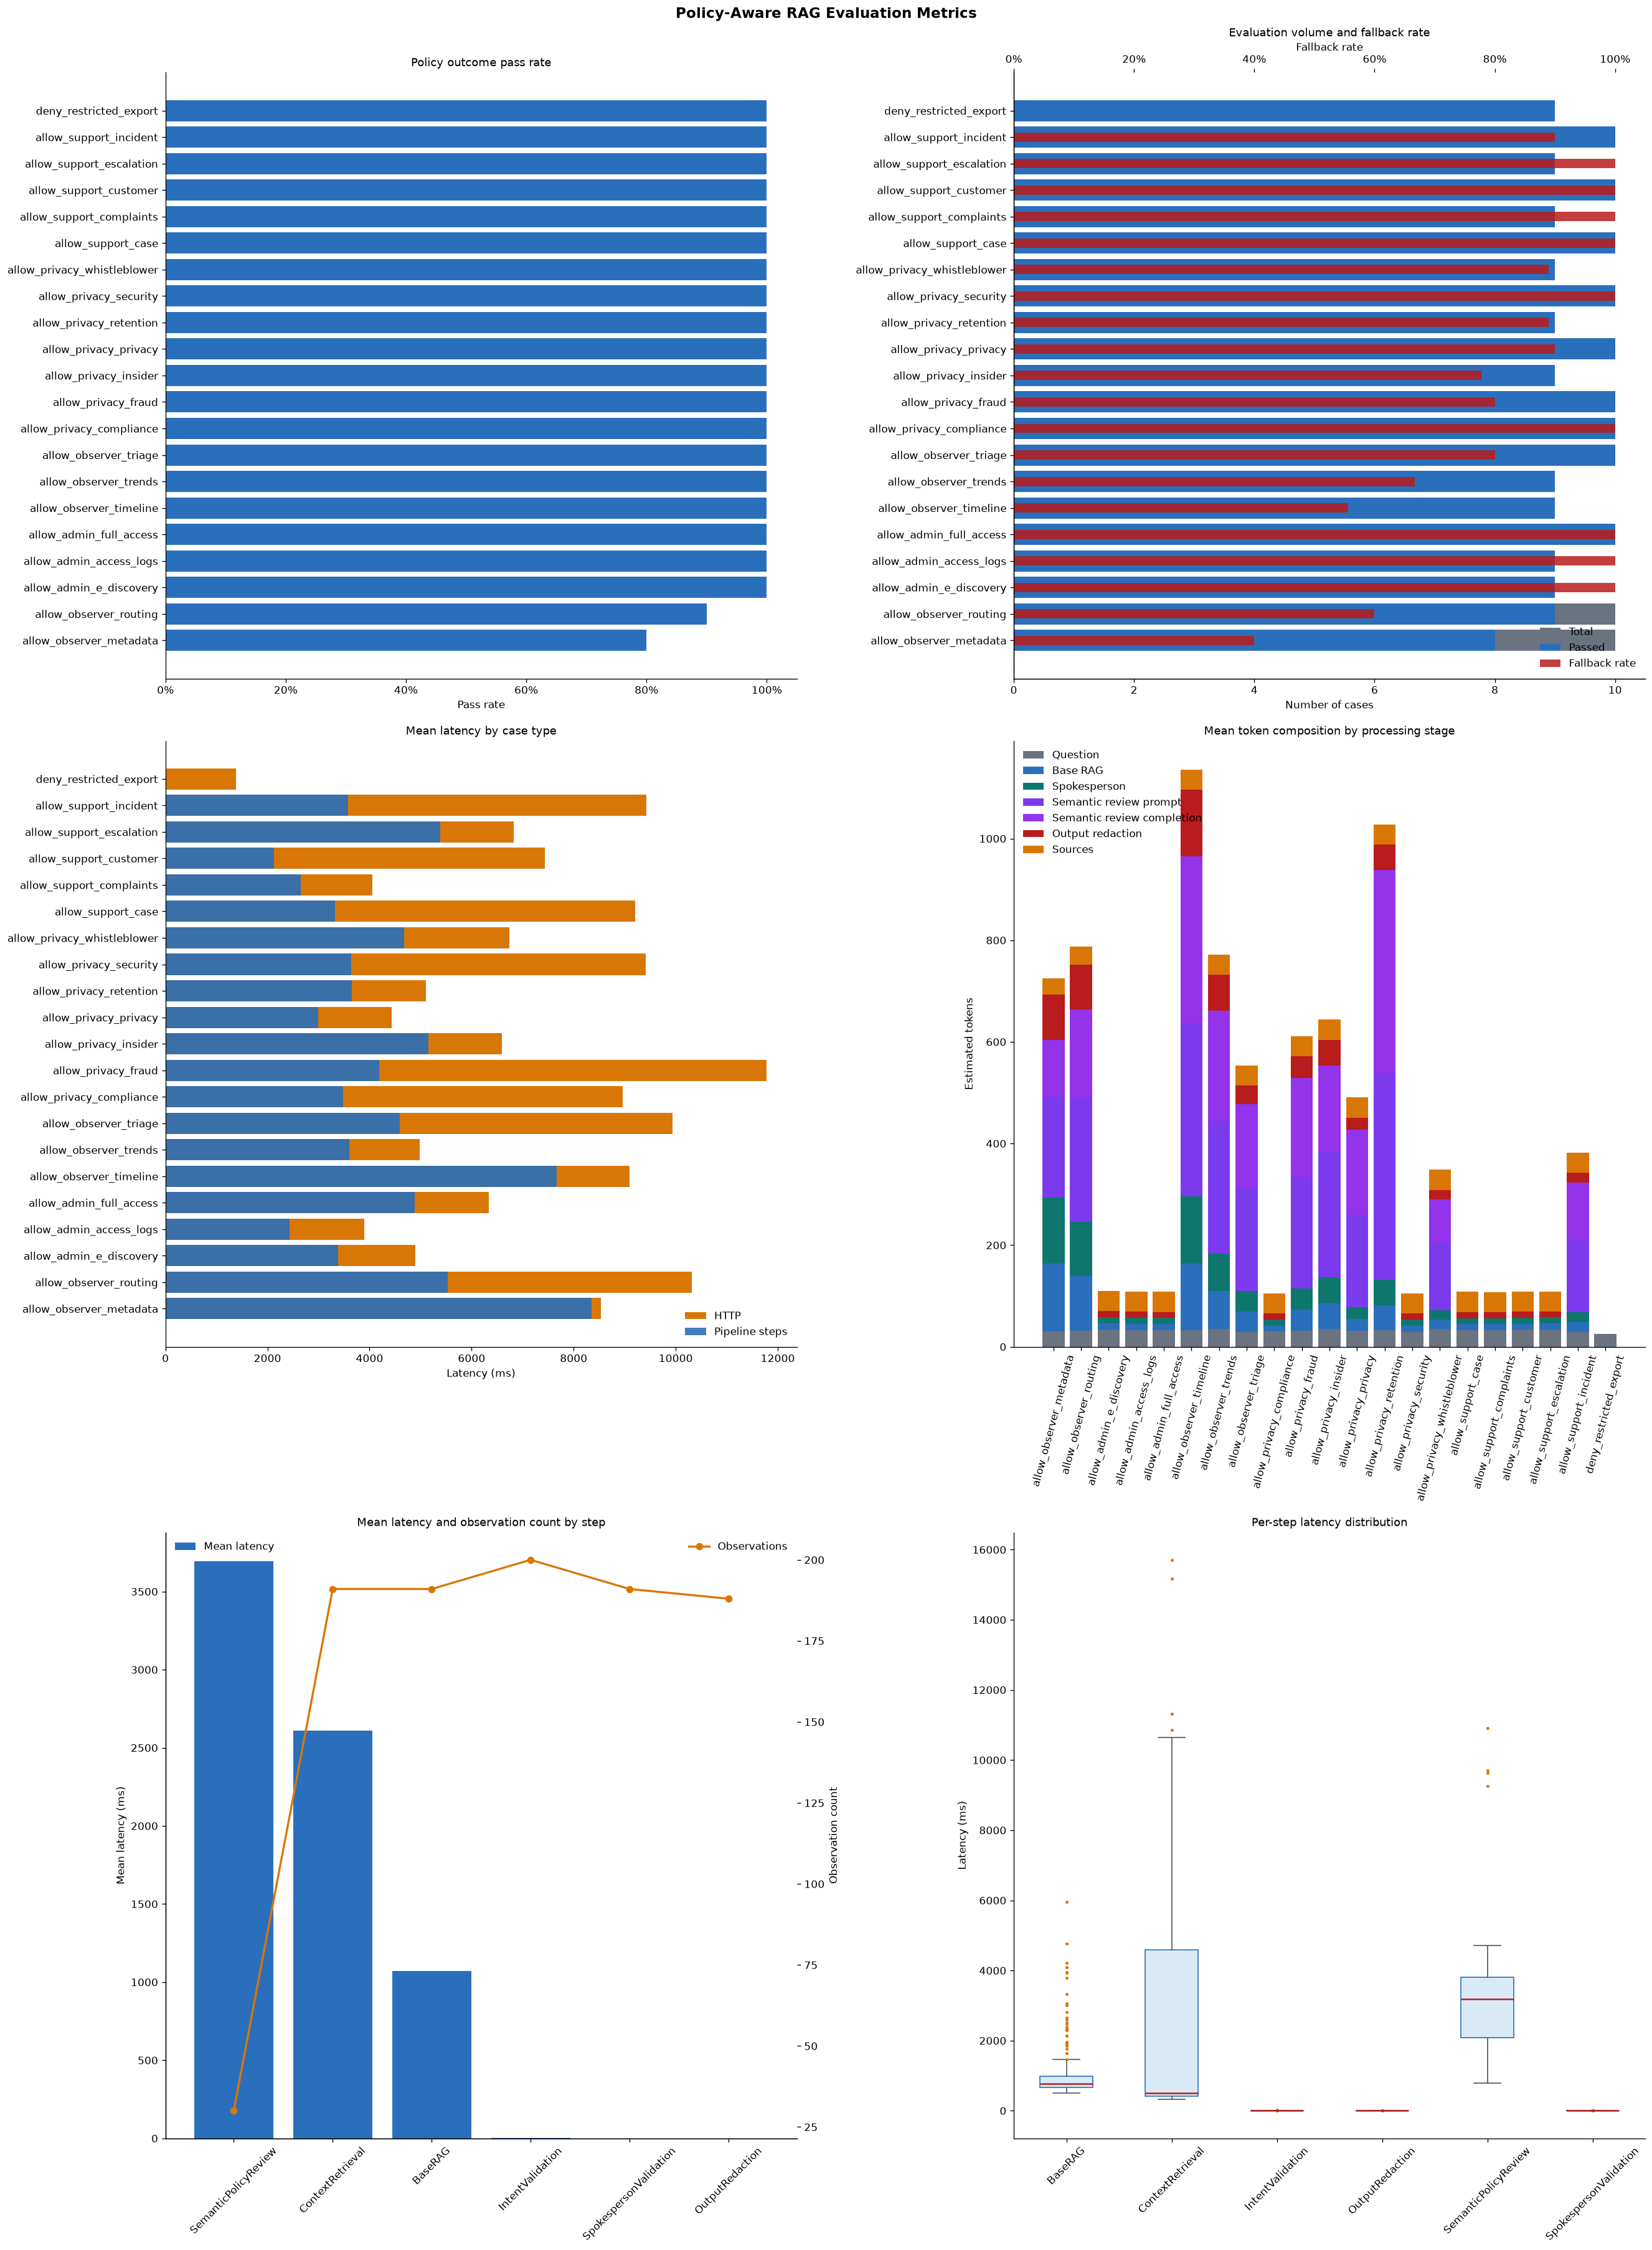

Saved figures to C:\Users\dillo\Source\Repos\PolicyAwareRAG\tests\performance_evaluation\figures


In [20]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

plot_summary = summary.sort_values('pass_rate').copy()
fig, axes = plt.subplots(3, 2, figsize=(22, 30), constrained_layout=True)

axes[0, 0].barh(plot_summary['case_type'], plot_summary['pass_rate'], color='#2A6FBB')
axes[0, 0].set_title('Policy outcome pass rate')
axes[0, 0].set_xlabel('Pass rate')
axes[0, 0].set_xlim(0, 1.05)
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))

axes[0, 1].barh(plot_summary['case_type'], plot_summary['total'], color='#6B7280', label='Total')
axes[0, 1].barh(plot_summary['case_type'], plot_summary['passed'], color='#2A6FBB', label='Passed')
axes[0, 1].set_title('Evaluation volume and fallback rate')
axes[0, 1].set_xlabel('Number of cases')
volume_handles, volume_labels = axes[0, 1].get_legend_handles_labels()
fallback_axis = axes[0, 1].twiny()
fallback_axis.barh(
    plot_summary['case_type'],
    plot_summary['fallback_rate'],
    height=0.35,
    color='#B91C1C',
    alpha=0.85,
    label='Fallback rate',
)
fallback_axis.set_xlim(0, 1.05)
fallback_axis.set_xlabel('Fallback rate')
fallback_axis.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))
fallback_handles, fallback_labels = fallback_axis.get_legend_handles_labels()
axes[0, 1].legend(
    volume_handles + fallback_handles,
    volume_labels + fallback_labels,
    frameon=False,
    loc='lower right',
)

axes[1, 0].barh(plot_summary['case_type'], plot_summary['avg_http_latency_ms'], color='#D97706', label='HTTP')
axes[1, 0].barh(plot_summary['case_type'], plot_summary['avg_step_latency_ms'], color='#2A6FBB', alpha=0.9, label='Pipeline steps')
axes[1, 0].set_title('Mean latency by case type')
axes[1, 0].set_xlabel('Latency (ms)')
axes[1, 0].legend(frameon=False, loc='lower right')

# Include the secondary semantic review as its own token-consuming stage.
token_columns = [
    'avg_question_tokens',
    'avg_base_rag_tokens',
    'avg_spokesperson_tokens',
    'avg_semantic_review_prompt_tokens',
    'avg_semantic_review_completion_tokens',
    'avg_output_redaction_tokens',
    'avg_source_tokens',
]
token_labels = ['Question', 'Base RAG', 'Spokesperson', 'Semantic review prompt', 'Semantic review completion', 'Output redaction', 'Sources']
token_colors = ['#6B7280', '#2A6FBB', '#0F766E', '#7C3AED', '#9333EA', '#B91C1C', '#D97706']
left = pd.Series(0.0, index=plot_summary.index)
for column, label, color in zip(token_columns, token_labels, token_colors):
    axes[1, 1].bar(plot_summary['case_type'], plot_summary[column], bottom=left, label=label, color=color)
    left = left + plot_summary[column]
axes[1, 1].set_title('Mean token composition by processing stage')
axes[1, 1].set_ylabel('Estimated tokens')
axes[1, 1].tick_params(axis='x', rotation=75)
axes[1, 1].legend(frameon=False, loc='upper left')

if not steps_df.empty:
    step_summary = steps_df.groupby('stepName').agg(
        step_count=('stepName', 'size'),
        avg_latency_ms=('latency_ms', 'mean'),
    ).sort_values('avg_latency_ms', ascending=False)
    step_axis = axes[2, 0]
    step_axis.bar(step_summary.index, step_summary['avg_latency_ms'], color='#2A6FBB')
    step_axis.set_title('Mean latency and observation count by step')
    step_axis.set_ylabel('Mean latency (ms)')
    step_axis.tick_params(axis='x', rotation=45)
    count_axis = step_axis.twinx()
    count_axis.plot(step_summary.index, step_summary['step_count'], color='#D97706', marker='o', linewidth=2, label='Observations')
    count_axis.set_ylabel('Observation count')
    count_axis.spines.top.set_visible(False)
    step_axis.legend(['Mean latency'], frameon=False, loc='upper left')
    count_axis.legend(frameon=False, loc='upper right')
else:
    axes[2, 0].text(0.5, 0.5, 'No step telemetry available', ha='center', va='center')
    axes[2, 0].set_axis_off()

if not steps_df.empty:
    step_latency = steps_df.groupby('stepName')['latency_ms'].apply(list)
    axes[2, 1].boxplot(
        step_latency.tolist(),
        tick_labels=step_latency.index,
        patch_artist=True,
        boxprops={'facecolor': '#D9EAF7', 'edgecolor': '#2A6FBB'},
        medianprops={'color': '#B91C1C', 'linewidth': 1.5},
        whiskerprops={'color': '#4B5563'},
        capprops={'color': '#4B5563'},
        flierprops={'marker': 'o', 'markerfacecolor': '#D97706', 'markersize': 3, 'markeredgecolor': 'none'},
    )
    axes[2, 1].set_title('Per-step latency distribution')
    axes[2, 1].set_ylabel('Latency (ms)')
    axes[2, 1].tick_params(axis='x', rotation=45)
else:
    axes[2, 1].text(0.5, 0.5, 'No step telemetry available', ha='center', va='center')
    axes[2, 1].set_axis_off()

fig.suptitle('Policy-Aware RAG Evaluation Metrics', fontsize=14, fontweight='bold')
fig.savefig(FIGURES_DIR / 'evaluation_metrics.png', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'evaluation_metrics.svg', bbox_inches='tight')
plt.show()
print(f'Saved figures to {FIGURES_DIR.resolve()}')

In [21]:
if HAS_RAGAS:
    import re

    reference_answers_path = Path('reference_answers.json')
    if not reference_answers_path.exists():
        reference_answers_path = Path('tests/performance_evaluation/reference_answers.json')
    reference_answers = {}
    if reference_answers_path.exists():
        reference_answers = json.loads(reference_answers_path.read_text(encoding='utf-8'))

    def normalize_reference_lookup(value):
        text = str(value or '').lower()
        text = re.sub(r'[^a-z0-9]+', ' ', text)
        return ' '.join(text.split())

    normalized_reference_answers = {
        normalize_reference_lookup(question): answer
        for question, answer in reference_answers.items()
    }

    ragas_rows = []
    for row in df.itertuples():
        record = row._asdict()
        final_answer = str(record.get('response', {}).get('answer', '') if isinstance(record.get('response'), dict) else '')
        base_answer = str(record.get('base_answer') or final_answer)
        contexts = record.get('evaluation_contexts') or []
        question = record.get('question') or record.get('original_prompt') or ''
        reference = (
            record.get('reference')
            or record.get('reference_answer')
            or normalized_reference_answers.get(normalize_reference_lookup(question))
        )
        if not final_answer:
            continue

        dataset_values = {
            'question': [question],
            'answer': [final_answer],
            'contexts': [[str(item) for item in contexts]],
        }
        metrics = list(ragas_metrics)
        if reference:
            dataset_values['reference'] = [str(reference)]
            metrics.extend(reference_metrics)

        dataset = Dataset.from_dict(dataset_values)
        scores = evaluate(dataset, metrics=metrics)
        final_scores = scores.scores[0]
        row_scores = {
            'case_type': record.get('case_type'),
            'is_fallback': bool(record.get('is_fallback', False)),
            'has_reference': bool(reference),
            **{f'final_{k}': float(v) for k, v in final_scores.items() if isinstance(v, (int, float))},
        }
        if base_answer != final_answer:
            base_dataset = Dataset.from_dict({
                'question': [question],
                'answer': [base_answer],
                'contexts': [[str(item) for item in contexts]],
            })
            base_scores = evaluate(base_dataset, metrics=ragas_metrics)
            row_scores.update({
                f'base_{k}': float(v) for k, v in base_scores.scores[0].items() if isinstance(v, (int, float))
            })
        ragas_rows.append(row_scores)

    if ragas_rows:
        ragas_df = pd.DataFrame(ragas_rows)
        ragas_summary = ragas_df.groupby('case_type').agg(
            fallback_rate=('is_fallback', 'mean'),
            reference_coverage=('has_reference', 'mean'),
        ).join(
            ragas_df.groupby('case_type').mean(numeric_only=True).drop(
                columns=['is_fallback', 'has_reference'], errors='ignore'
            ),
            how='right',
        )
        display(ragas_summary.round(3))
        print(
            f"Context Precision reference coverage: "
            f"{int(ragas_df['has_reference'].sum())}/{len(ragas_df)} "
            f"({ragas_df['has_reference'].mean():.1%})"
        )
    else:
        print('No answer-bearing records are available for RAGAS evaluation.')
else:
    print('RAGAS is not installed or Azure Foundry settings are unavailable; showing proxy pass-rate summary instead.')
    display(df.groupby('case_type').agg(
        pass_rate=('passed', 'mean'),
        fallback_rate=('is_fallback', 'mean'),
    ).round(3))

Evaluating:  33%|███▎      | 1/3 [00:03<00:06,  3.10s/it]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Users\dillo\AppData\Local\Python\pythoncore-3.13-64\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000001BA4518A680> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-12889' coro=<_async_in_context.<locals>.run_in_context() done, defined at c:\Users\dillo\Source\Repos\PolicyAwareRAG\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-12890' coro=<Kernel.shell_main() running at c:\Users\dillo\Source\Repos\PolicyAwareRAG\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at c:\Users\dillo\Source\Repos\PolicyAwareRAG\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564

KeyboardInterrupt: 

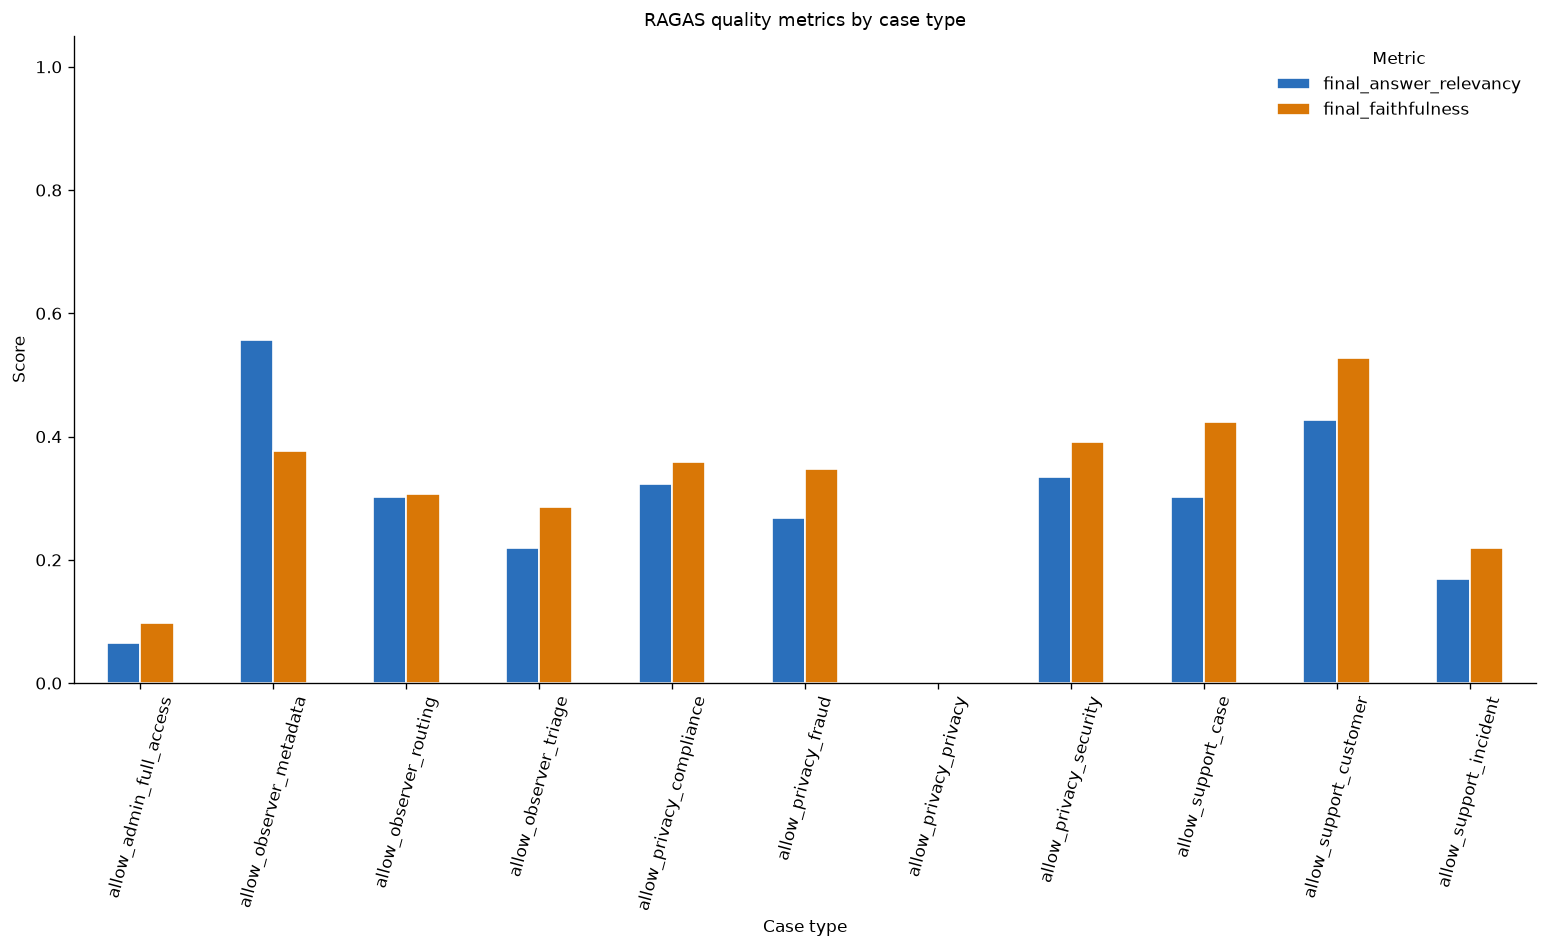

Saved RAGAS figures to C:\Users\dillo\Source\Repos\PolicyAwareRAG\tests\performance_evaluation\figures


In [ ]:
if 'ragas_df' in globals() and not ragas_df.empty:
    metric_columns = [
        'final_context_precision',
        'final_faithfulness',
        'final_answer_relevancy',
    ]
    available_metrics = [column for column in metric_columns if column in ragas_df.columns]
    if available_metrics:
        ragas_plot = ragas_df.groupby('case_type')[available_metrics].mean().sort_index()
        ax = ragas_plot.plot(
            kind='bar',
            figsize=(13, 8),
            color=['#2A6FBB', '#D97706', '#0F766E'],
            edgecolor='white',
        )
        ax.set_title('RAGAS metrics by case type')
        ax.set_xlabel('Case type')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis='x', rotation=75)
        ax.legend(
            title='Metric',
            labels=['Context Precision', 'Faithfulness', 'Answer Relevance'],
            frameon=False,
        )
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1f}'))
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'ragas_metrics.png', dpi=300, bbox_inches='tight')
        plt.savefig(FIGURES_DIR / 'ragas_metrics.svg', bbox_inches='tight')
        plt.show()
        print(f'Saved RAGAS figures to {FIGURES_DIR.resolve()}')
    else:
        print('No requested RAGAS metric columns are available for charting.')
else:
    print('No RAGAS results available for charting.')